In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist
from multi_layer_net import MultiLayerNet

In [2]:
def shuffle_dataset(x, t):
    permutation = np.random.permutation(x.shape[0])
    x = x[permutation,:] if x.ndim == 2 else x[permutation,:,:,:]
    t = t[permutation]

    return x, t

In [3]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [4]:
class Trainer:
    """신경망 훈련을 대신 해주는 클래스
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01}, 
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimzer
        optimizer_class_dict = {'sgd':SGD}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0
        
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]
        
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
        
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))
        
        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1
            
            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]
                
            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

In [5]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)
x_train = x_train[:500]
t_train = t_train[:500]

validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

In [6]:
def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list

In [7]:
# 하이퍼파라미터 무작위 탐색======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 탐색한 하이퍼파라미터의 범위 지정===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

val acc:0.16 | lr:0.00020897968582871362, weight decay:2.953094862052715e-05
val acc:0.33 | lr:0.0018192266156215526, weight decay:2.3904826098937754e-05
val acc:0.47 | lr:0.0033330334136415837, weight decay:5.672135977079926e-08
val acc:0.02 | lr:2.685407956321746e-05, weight decay:4.035985311349073e-08
val acc:0.08 | lr:2.1695326295858938e-06, weight decay:9.139453596792319e-06
val acc:0.13 | lr:0.0005634964384928779, weight decay:6.470112677362198e-08
val acc:0.4 | lr:0.001591613416032111, weight decay:1.049753136436198e-05
val acc:0.43 | lr:0.002761145543355622, weight decay:1.0932483563447615e-06
val acc:0.09 | lr:0.00011726383468111804, weight decay:7.315182750277064e-06
val acc:0.1 | lr:1.0551635174899447e-05, weight decay:9.039009043787978e-07
val acc:0.12 | lr:0.00010044520499558335, weight decay:6.830781712199217e-07
val acc:0.27 | lr:0.0015374778988747864, weight decay:1.2485858060033023e-08
val acc:0.08 | lr:1.1295495902612187e-05, weight decay:7.783312271582181e-08
val acc

=========== Hyper-Parameter Optimization Result ===========
Best-1(val acc:0.8) | lr:0.009923111666963217, weight decay:2.819511048065071e-08
Best-2(val acc:0.77) | lr:0.006470363976953217, weight decay:6.932815697773417e-06
Best-3(val acc:0.72) | lr:0.009202675117206922, weight decay:1.5300925583536505e-06
Best-4(val acc:0.7) | lr:0.007541237824157268, weight decay:3.793517241413079e-06
Best-5(val acc:0.67) | lr:0.006509699858229418, weight decay:4.136762626775758e-06
Best-6(val acc:0.47) | lr:0.0033330334136415837, weight decay:5.672135977079926e-08
Best-7(val acc:0.43) | lr:0.002761145543355622, weight decay:1.0932483563447615e-06
Best-8(val acc:0.4) | lr:0.001591613416032111, weight decay:1.049753136436198e-05
Best-9(val acc:0.39) | lr:0.0032004170827432065, weight decay:2.916570503664786e-05
Best-10(val acc:0.38) | lr:0.00269374898879508, weight decay:2.846158361211552e-08
Best-11(val acc:0.37) | lr:0.002258514557456092, weight decay:1.154400430381236e-05
Best-12(val acc:0.37) | l

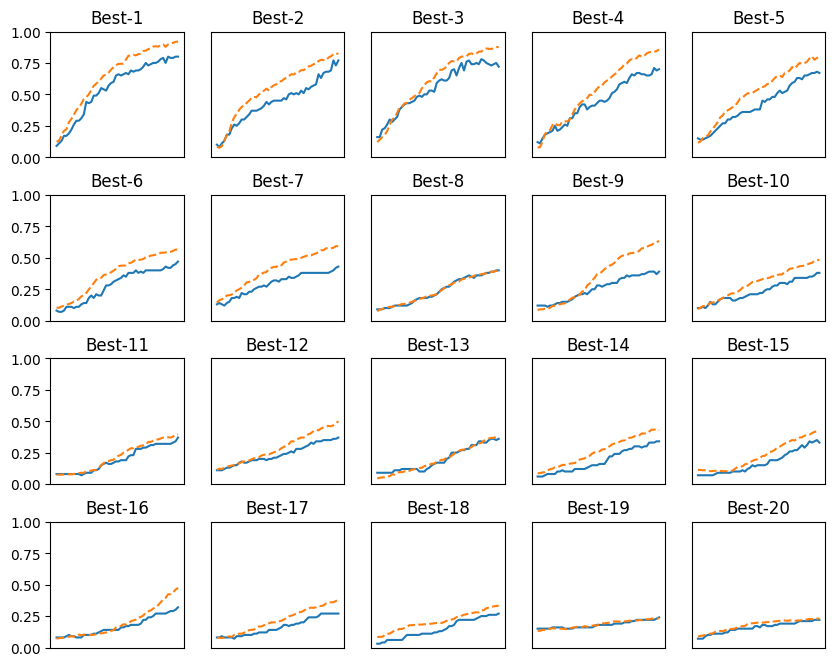

In [8]:
# 그래프 그리기========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

plt.figure(figsize=(10, 8))

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.subplots_adjust(wspace=0.2, hspace=0.3)    
plt.show()